In [1]:
import pandas as pd # for dataframe/scripts
import numpy as np # numerical computation
import matplotlib.pyplot as plt # visualization
import seaborn as sns # visualization

from sklearn.preprocessing import OneHotEncoder # preprocessing
from sklearn.model_selection import train_test_split # model training
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error # for evaluation (accuracy)

from sklearn.linear_model import LinearRegression 
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV # model selection

import joblib # to generate .pkl file
import warnings
warnings.filterwarnings(action = 'ignore')

from pathlib import Path

In [2]:
car_df = pd.read_csv("cardekho_dataset.csv")
car_df.head()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [3]:
car_df.shape

(15411, 14)

In [4]:
car_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15411 non-null  int64  
 1   car_name           15411 non-null  object 
 2   brand              15411 non-null  object 
 3   model              15411 non-null  object 
 4   vehicle_age        15411 non-null  int64  
 5   km_driven          15411 non-null  int64  
 6   seller_type        15411 non-null  object 
 7   fuel_type          15411 non-null  object 
 8   transmission_type  15411 non-null  object 
 9   mileage            15411 non-null  float64
 10  engine             15411 non-null  int64  
 11  max_power          15411 non-null  float64
 12  seats              15411 non-null  int64  
 13  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(6), object(6)
memory usage: 1.6+ MB


In [5]:
car_df['brand'].value_counts().head(10)

brand
Maruti        4992
Hyundai       2982
Honda         1485
Mahindra      1011
Toyota         793
Ford           790
Volkswagen     620
Renault        536
BMW            439
Tata           430
Name: count, dtype: int64

In [6]:
car_df['car_name'].value_counts().head(20)

car_name
Hyundai i20           906
Maruti Swift Dzire    890
Maruti Swift          781
Maruti Alto           778
Honda City            757
Maruti Wagon R        717
Hyundai Grand         580
Toyota Innova         545
Hyundai Verna         492
Hyundai i10           410
Ford Ecosport         374
Volkswagen Polo       373
Maruti Baleno         364
Honda Amaze           362
Maruti Ciaz           346
Maruti Ertiga         343
Hyundai Creta         336
Mahindra XUV500       330
Renault KWID          306
Maruti Vitara         295
Name: count, dtype: int64

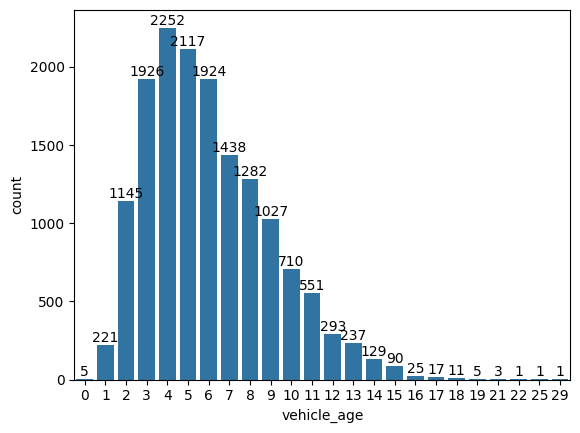

In [7]:
ax = sns.countplot(data=car_df, x = "vehicle_age")
plt.xticks()
for b in ax.containers:
    ax.bar_label(b)
plt.show()

In [8]:
car_df[car_df["km_driven"] > 50000].count()

Unnamed: 0           7467
car_name             7467
brand                7467
model                7467
vehicle_age          7467
km_driven            7467
seller_type          7467
fuel_type            7467
transmission_type    7467
mileage              7467
engine               7467
max_power            7467
seats                7467
selling_price        7467
dtype: int64

In [9]:
car_df.drop(columns = ["Unnamed: 0"], inplace=True )

In [10]:
car_df.head()

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [11]:
# 1500 km < gureko 10 < year

car_df.columns

Index(['car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type',
       'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power',
       'seats', 'selling_price'],
      dtype='object')

In [12]:
car_df[(car_df["km_driven"]<1500) & (car_df["vehicle_age"]<10)].shape[0]

30

#### Data Cleaning

In [13]:
# remove unrealistic records

cleaned_car_df = car_df[(car_df["km_driven"]<500000) &
                        (car_df["vehicle_age"]<=15)]

In [14]:
cleaned_car_df.head()

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [15]:
# correct fuel type

cleaned_car_df["fuel_type"].unique()

array(['Petrol', 'Diesel', 'CNG', 'LPG', 'Electric'], dtype=object)

In [16]:
cleaned_car_df["fuel_type"].replace(
    "Electric",
    "Hybrid",
    inplace=True
)

In [17]:
# transmission analysis 
cleaned_car_df["transmission_type"].value_counts()

transmission_type
Manual       12158
Automatic     3175
Name: count, dtype: int64

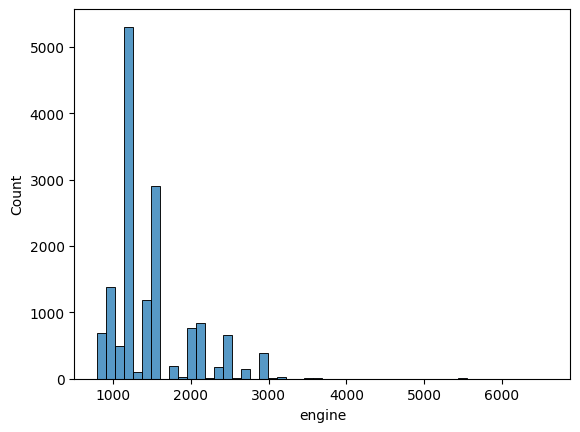

In [18]:
sns.histplot(data=cleaned_car_df, 
             x="engine",
             bins = 50)
plt.show()

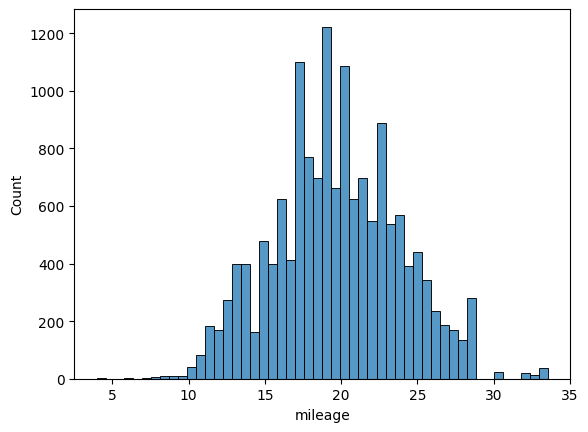

In [19]:
sns.histplot(data=cleaned_car_df, 
             x= "mileage",
             bins = 50)
plt.show()

In [20]:
cleaned_car_df["seats"].value_counts()

seats
5    12843
7     1913
8      310
6      127
4       77
9       55
2        7
0        1
Name: count, dtype: int64

In [21]:
cleaned_car_df.loc[cleaned_car_df["car_name"] == "Nissan Kicks", "seats"] = 5

In [22]:
cleaned_car_df["seats"].value_counts()

seats
5    12844
7     1913
8      310
6      127
4       77
9       55
2        7
Name: count, dtype: int64

In [23]:
# convert price to lakhs 

cleaned_car_df["selling_price_in_lakhs"] = (cleaned_car_df["selling_price"]/100000)

cleaned_car_df.drop(["selling_price"],
                    axis=1,
                    inplace=True)

In [24]:
cleaned_car_df.head()

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price_in_lakhs
0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,1.20
1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,5.50
2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,2.15
3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,2.26
4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,5.70


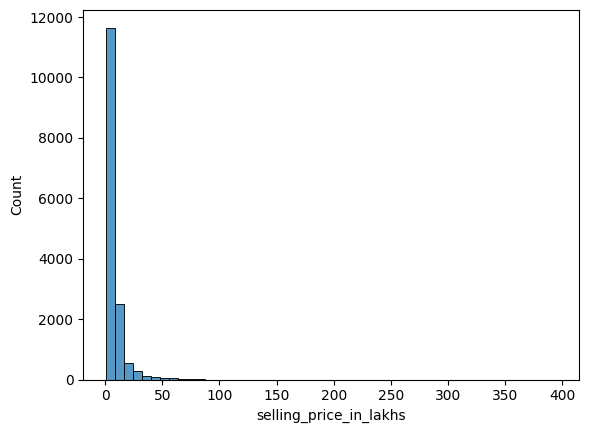

In [25]:
# price distribution analysis in lakhs

sns.histplot(data=cleaned_car_df,
             x="selling_price_in_lakhs",
             bins = 50)
plt.show()

In [26]:
cleaned_car_df["vehicle_age"].value_counts()

vehicle_age
4     2250
5     2114
3     1926
6     1921
7     1438
8     1282
2     1144
9     1024
10     709
11     551
12     293
13     236
1      221
14     129
15      90
0        5
Name: count, dtype: int64

In [27]:
cleaned_car_df["vehicle_age"] = (
    cleaned_car_df["vehicle_age"].replace(0,1)
)

### feature engineering

- create new features to improve model performance

In [28]:
cleaned_car_df["km_driven_per_year"] = (
    cleaned_car_df["km_driven"] / cleaned_car_df["vehicle_age"]
)

cleaned_car_df["power_to_engine_ratio"] = (
    cleaned_car_df["max_power"] * 1000 / cleaned_car_df["engine"]
)

In [29]:
cleaned_car_df.head()

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price_in_lakhs,km_driven_per_year,power_to_engine_ratio
0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,1.20,13333.333333,58.165829
1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,5.50,4000.000000,68.504595
2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,2.15,5454.545455,66.833751
3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,2.26,4111.111111,67.234469
4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,5.70,5000.000000,65.814419


### check skewness

In [30]:
cleaned_car_df["selling_price_in_lakhs"].skew()

np.float64(10.05432437282755)

In [31]:
cleaned_car_df["vehicle_age"].skew()

np.float64(0.6808206990042633)

In [32]:
cleaned_car_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15333 entries, 0 to 15410
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   car_name                15333 non-null  object 
 1   brand                   15333 non-null  object 
 2   model                   15333 non-null  object 
 3   vehicle_age             15333 non-null  int64  
 4   km_driven               15333 non-null  int64  
 5   seller_type             15333 non-null  object 
 6   fuel_type               15333 non-null  object 
 7   transmission_type       15333 non-null  object 
 8   mileage                 15333 non-null  float64
 9   engine                  15333 non-null  int64  
 10  max_power               15333 non-null  float64
 11  seats                   15333 non-null  int64  
 12  selling_price_in_lakhs  15333 non-null  float64
 13  km_driven_per_year      15333 non-null  float64
 14  power_to_engine_ratio   15333 non-null  flo

In [33]:
numerical_cols = [
    'vehicle_age',
    'km_driven',
    'mileage',
    'engine',
    'max_power',
    'seats',
    'selling_price_in_lakhs',
    'km_driven_per_year',
    'power_to_engine_ratio'
]

skewness = cleaned_car_df[numerical_cols].skew()
print("\nSkewness of Numerical Features:")
print(skewness.sort_values(ascending=False))


Skewness of Numerical Features:
selling_price_in_lakhs    10.054324
km_driven_per_year         3.594275
max_power                  2.491997
km_driven                  2.097907
seats                      2.091150
engine                     1.673688
vehicle_age                0.680821
power_to_engine_ratio      0.331678
mileage                    0.104431
dtype: float64


In [34]:
log_cols = [
    "km_driven",
    "engine",
    "max_power",
    "km_driven_per_year",
    "selling_price_in_lakhs"
]

for col in log_cols:
    cleaned_car_df[col] = np.log1p(cleaned_car_df[col])

In [35]:
cleaned_car_df['seats']=(
    cleaned_car_df['seats'].astype(str)
)

encoder = OneHotEncoder(
    sparse_output=False,
    handle_unknown="ignore"
)

categorical_columns = [
    "model",
    "seats",
    "brand",
    "seller_type",
    "fuel_type",
    "transmission_type"
]

encoded_data = encoder.fit_transform(cleaned_car_df[categorical_columns])

encoded_feature_names = encoder.get_feature_names_out(categorical_columns)


In [36]:
df_encoded = pd.DataFrame(
    encoded_data,
    columns=encoded_feature_names,
    index=cleaned_car_df.index
)

In [37]:
encoded_df = pd.concat(
    [
        cleaned_car_df.drop(columns=categorical_columns),
        df_encoded
    ],
    axis=1
)

encoded_df = pd.concat(
    [
        cleaned_car_df.drop(
            columns=categorical_columns + ["car_name"]
        ),
        df_encoded
    ],
    axis=1
)

In [38]:
X = encoded_df.drop(
    "selling_price_in_lakhs",
    axis = 1
)

y = encoded_df["selling_price_in_lakhs"]

X_train, X_test,y_train, y_test = train_test_split(X,y, test_size=0.2 ,random_state=42)

In [39]:
models = {
    "Linear Regression" : LinearRegression(),
    "Decision Tree" : DecisionTreeRegressor(
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42
    ),
    "Random Forest Regressor" : RandomForestRegressor(
        n_estimators=300,
        max_depth=20,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1
    ),
    "XGB Regressor" : XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        objective="reg:squarederror"
    )
}

In [40]:

results = []
trained_models = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    trained_models[name] = model

    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results.append({
        "Model": name,
        "R2 Score": round(r2, 4),
        "MAE": round(mae, 4),
        "RMSE": round(rmse, 4)
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="R2 Score",
    ascending=False
)

print(results_df)

                     Model  R2 Score     MAE    RMSE
3            XGB Regressor    0.9494  0.0984  0.1306
2  Random Forest Regressor    0.9302  0.1121  0.1534
0        Linear Regression    0.9237  0.1175  0.1603
1            Decision Tree    0.9184  0.1198  0.1659


In [43]:
best_xgb = trained_models["XGB Regressor"]

In [44]:
importances = best_xgb.feature_importances_

for imp, feat in zip(importances, X_train.columns):
    if imp > 0.05:
        print(f"{feat}: {imp:.4f}")

max_power: 0.2421
transmission_type_Automatic: 0.0615


In [47]:
y_pred = best_xgb.predict(X_test)

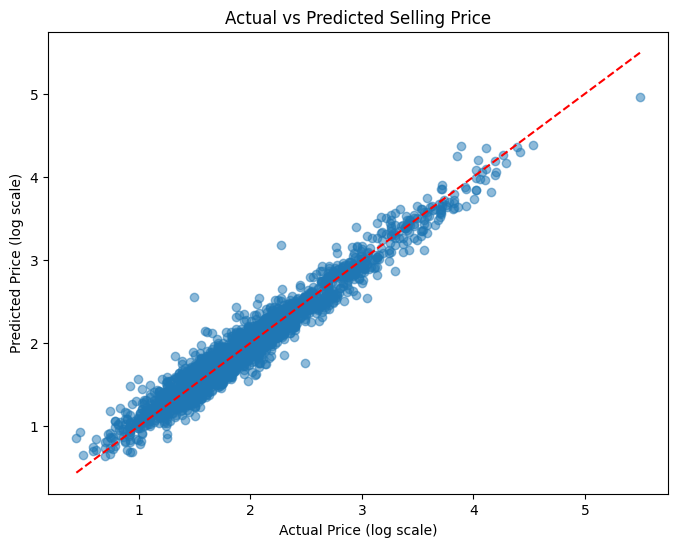

In [48]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.xlabel("Actual Price (log scale)")
plt.ylabel("Predicted Price (log scale)")
plt.title("Actual vs Predicted Selling Price")

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.show()